# PeMS04 Exploratory Analysis — CIVL 6962 Homework 1

Dataset: **PeMS04** (Caltrans PeMS, District 4 — San Francisco Bay Area), 307 loop
detectors, 5-minute intervals, 2018-01-01 to 2018-02-28. Channels: `flow` (veh/5min),
`occupancy` (fraction 0-1), `speed` (mph).

This notebook documents the analysis behind `app.py`, in the order it was developed:

1. Load data & basic stats
2. Time series / distribution / fundamental-diagram EDA
3. Recovering road topology (sensor index order is NOT road order)
4. Turning the topology into a full 307-sensor sequence
5. Anomaly screening: "speed drops while occupancy stays flat" as an early-warning signal


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Load data

In [2]:
raw = np.load("data/pems04.npz")["data"]   # shape: (timesteps, sensors, [flow, occupancy, speed])
n_time, n_sensors, n_features = raw.shape
print(f"timesteps={n_time:,}  sensors={n_sensors}  features={n_features}")

time_index = pd.date_range("2018-01-01", periods=n_time, freq="5min")
sensor_ids = [f"D4-{i:03d}" for i in range(n_sensors)]

df = pd.DataFrame(raw.reshape(n_time * n_sensors, 3), columns=["flow", "occupancy", "speed"])
df["time"] = np.repeat(time_index, n_sensors)
df["sensor"] = np.tile(sensor_ids, n_time)
df = df[["time", "sensor", "flow", "occupancy", "speed"]]
df.head()

timesteps=16,992  sensors=307  features=3


,time,sensor,flow,occupancy,speed
0,2018-01-01,D4-000,62.0,0.0077,67.9
1,2018-01-01,D4-001,56.0,0.0112,68.4
2,2018-01-01,D4-002,90.0,0.0143,68.2
3,2018-01-01,D4-003,32.0,0.0074,66.3
4,2018-01-01,D4-004,19.0,0.0073,65.4


## 2. Basic stats & distributions

In [3]:
df[["flow", "occupancy", "speed"]].describe().round(3)

,flow,occupancy,speed
count,5216544.000,5216544.000,5216544.000
mean,211.701,0.053,63.471
std,158.068,0.049,8.356
min,0.000,0.000,3.000
25%,81.000,0.021,62.500
50%,180.000,0.044,65.600
75%,319.000,0.069,67.800
max,919.000,0.772,85.200


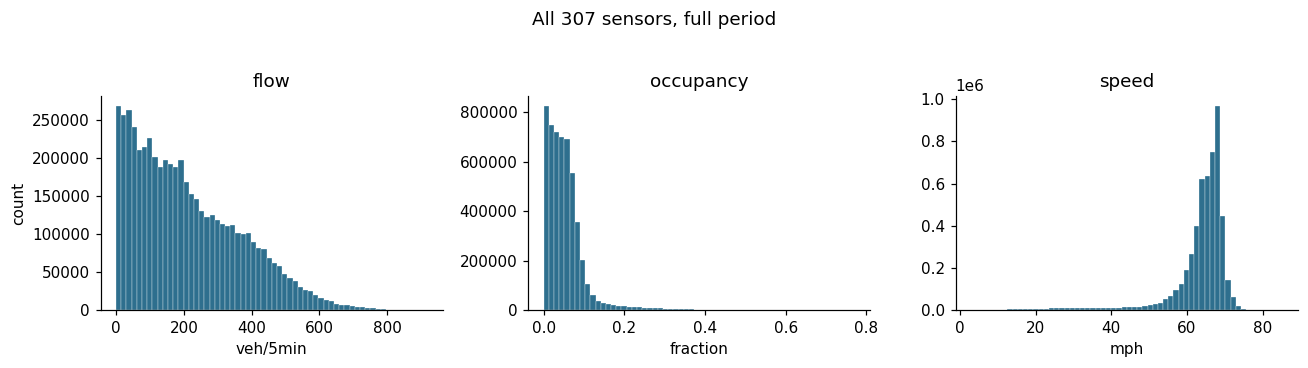

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, col, unit in zip(axes, ["flow","occupancy","speed"], ["veh/5min","fraction","mph"]):
    ax.hist(df[col], bins=60, color="#2E6F8E", edgecolor="white", linewidth=0.2)
    ax.set_title(col); ax.set_xlabel(unit)
axes[0].set_ylabel("count")
fig.suptitle("All 307 sensors, full period", y=1.03)
fig.tight_layout(); plt.show()

## 3. Recovering road topology

Sensor index order (`D4-000`, `D4-001`, ...) is **not** road order — adjacent indices show
essentially the same correlation as random pairs (~0.55-0.58). The real adjacency graph is
published separately alongside the PeMS04 benchmark: `distance.csv` (`from, to, cost`), from
the ASTGCN paper's repository (Davidham3/ASTGCN on GitHub). We validate it by checking that
edge-connected sensor pairs correlate much more strongly than random pairs.

In [5]:
dist = pd.read_csv("data/pems04_distance.csv")
print(dist.shape, "edges,", pd.concat([dist["from"], dist["to"]]).nunique(), "nodes")

G = nx.DiGraph()
for _, r in dist.iterrows():
    G.add_edge(int(r["from"]), int(r["to"]), weight=r["cost"])

occ = raw[:, :, 1]
edge_corrs = [np.corrcoef(occ[:, int(r["from"])], occ[:, int(r["to"])])[0, 1] for _, r in dist.iterrows()]
rng = np.random.default_rng(0)
rand_pairs = rng.choice(n_sensors, size=(len(dist), 2))
rand_corrs = [np.corrcoef(occ[:, a], occ[:, b])[0, 1] for a, b in rand_pairs if a != b]

print(f"connected-pair mean correlation: {np.nanmean(edge_corrs):.3f}")
print(f"random-pair mean correlation:    {np.nanmean(rand_corrs):.3f}")
print(f"weakly connected components (= distinct roads): {nx.number_weakly_connected_components(G)}")

(340, 3) edges, 307 nodes


connected-pair mean correlation: 0.689
random-pair mean correlation:    0.573
weakly connected components (= distinct roads): 12


## 4. Full 307-sensor sequencing

The graph has 12 weakly connected components: 11 clean chains, and one 237-node component
with 14 on-ramps merging into a highway-interchange-like structure (14 in-degree-0 roots).
We assign every sensor a `(component_id, root_id, seq_pos)` triple via multi-source Dijkstra
per component, giving every one of the 307 sensors a position along its own road.

In [6]:
def build_sensor_sequence(G):
    rows = []
    comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    for comp_id, nodes in enumerate(comps):
        sub = G.subgraph(nodes)
        roots = [n for n in sub.nodes() if sub.in_degree(n) == 0] or \
                [min(sub.nodes(), key=lambda n: sub.in_degree(n))]
        best_dist = {n: np.inf for n in sub.nodes()}
        best_root = {n: None for n in sub.nodes()}
        for r in roots:
            for n, d in nx.single_source_dijkstra_path_length(sub, r, weight="weight").items():
                if d < best_dist[n]:
                    best_dist[n], best_root[n] = d, r
        for n in sub.nodes():
            rows.append({"sensor": f"D4-{n:03d}", "node_id": n, "component_id": comp_id,
                         "component_size": len(nodes), "root_id": best_root[n], "seq_pos": best_dist[n]})
    return pd.DataFrame(rows)

seq_df = build_sensor_sequence(G)
print(f"{len(seq_df)} sensors sequenced, {seq_df['seq_pos'].isna().sum()} missing")
seq_df.to_csv("data/sensor_sequence.csv", index=False)
seq_df.head()

307 sensors sequenced, 0 missing


,sensor,node_id,component_id,component_size,root_id,seq_pos
0,D4-073,73,0,237,73,0.0
1,D4-005,5,0,237,73,352.6
2,D4-154,154,0,237,73,699.8
3,D4-263,263,0,237,73,1092.7
4,D4-056,56,0,237,73,1533.5


## 5. Anomaly screening: an early-warning signal, not an incident detector

**Working definition.** At each 5-minute step, compare occupancy and speed to a rolling
15-minute anchor (mean of the previous 3 slots — a single previous point turned out to be too
noisy). Flag an **onset** when occupancy barely moved (within a small threshold) but speed
already dropped (below a small threshold) — occupancy is a lagging indicator (cars must pile
up before it rises), so a genuine slowdown often shows up in speed first.

**Why not call this "accident detection".** We tested whether onsets are followed by a real,
developing slowdown: 15-60 minutes later, most onsets still show reduced speed and rising
occupancy — consistent with the onset of ordinary congestion, not a one-off blip. We also
found that a naive "hasn't recovered yet" check is easily fooled: (a) broken sensors (stuck
values, or occupancy stuck at 0) look identical to a stalled recovery, and (b) comparing
against a whole-day median makes ~50% of all readings "below normal" by construction, so long
"unresolved" runs often just reflect an ordinary quiet period, not a real event. Given these
failure modes, and that there is no ground-truth incident log to validate against, we frame
this as a **screening tool**: it ranks locations by how often this pattern recurs, as
candidates for human follow-up (e.g. closer monitoring or ITS sensor placement) — not as a
confirmed-incident classifier.

In [7]:
occ, speed = raw[:, :, 1], raw[:, :, 2]

# malfunctioning sensor windows: occupancy stuck at 0 for 15+ min, or speed repeating for 25+ min
bad = np.zeros_like(occ, dtype=bool)
for s in range(n_sensors):
    z = occ[:, s] == 0
    run_id = (~z).cumsum()
    run_len = pd.Series(z).groupby(run_id).transform("sum") * z
    bad[:, s] |= run_len.values >= 3

    same = pd.Series(speed[:, s]).diff() == 0
    run_id2 = (~same).cumsum()
    run_len2 = same.groupby(run_id2).transform("sum") * same
    bad[:, s] |= run_len2.values >= 5

print(f"sensors with >=1% of time flagged as faulty: {(bad.mean(axis=0) > 0.01).sum()} / {n_sensors}")

sensors with >=1% of time flagged as faulty: 59 / 307


In [8]:
def rolling_prev_mean(x, w=3):
    return pd.DataFrame(x).shift(1).rolling(w, min_periods=w).mean().values

anchor_speed = rolling_prev_mean(speed)
anchor_occ = rolling_prev_mean(occ)
d_speed = (speed - anchor_speed) / np.where(anchor_speed == 0, np.nan, anchor_speed) * 100
d_occ = (occ - anchor_occ) / np.where(anchor_occ == 0, np.nan, anchor_occ) * 100

OCC_T, SPEED_T, MAX_H = 2.0, 1.0, 12   # occupancy %, speed %, cap tracking at 1 hour
valid = ~bad & np.isfinite(d_occ) & np.isfinite(d_speed)
onset = (np.abs(d_occ) <= OCC_T) & (d_speed <= -SPEED_T) & valid
print(f"onset triggers: {onset.sum():,} ({onset.sum()/valid.sum()*100:.2f}% of valid readings)")

events = []
for s in range(n_sensors):
    sp = speed[:, s]; b = bad[:, s]
    for t in np.where(onset[:, s])[0]:
        thresh = anchor_speed[t, s] * (1 - SPEED_T/100)
        h = 0
        while h < MAX_H and t + h < n_time and sp[t + h] < thresh and not b[t + h]:
            h += 1
        events.append((s, t, h * 5, h == MAX_H))

ev = pd.DataFrame(events, columns=["sensor", "start_t", "duration_min", "capped"])
ev["category"] = np.select(
    [ev["duration_min"] <= 15, ~ev["capped"]],
    ["transient", "sustained"], default="long_running")
print(ev["category"].value_counts())

onset triggers: 124,651 (2.44% of valid readings)


category
transient       79983
sustained       24313
long_running    20355
Name: count, dtype: int64


In [9]:
flagged = ev[ev["category"] != "transient"]
rank = flagged.groupby("sensor").size().sort_values(ascending=False)
print("Top 10 locations by flagged-event frequency (candidates for closer monitoring):")
for s, n in rank.head(10).items():
    print(f"  D4-{s:03d}: {n} events")

ev.to_csv("data/anomaly_events.csv", index=False)

Top 10 locations by flagged-event frequency (candidates for closer monitoring):
  D4-041: 320 events
  D4-203: 311 events
  D4-101: 303 events
  D4-082: 293 events
  D4-120: 284 events
  D4-053: 281 events
  D4-051: 276 events
  D4-085: 267 events
  D4-045: 262 events
  D4-072: 261 events


### Next steps

- `app.py` wraps steps 3-5 into an interactive dashboard: the topology layout and the
  malfunction/onset detection are cached, while the three homework-required controls
  (speed threshold, occupancy threshold, alarm level) recompute only what's needed.
- See the dashboard's blind-spot panel for the full list of caveats (virtual layout, no
  ground-truth validation for "anomaly" labels, sensor coverage gaps).